# Performance Testing

- general statistical methods for evaluation
- downstream task: train two models and use real data as validation set

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

In [3]:
real = pd.read_csv("../datasets/filtered.csv", engine="pyarrow")
synth = pd.read_csv("../output/before.csv", engine="pyarrow")
# before = pd.read_csv("../output/before-calib.csv", engine="pyarrow")
# after = pd.read_csv("../output/after-calib.csv", engine="pyarrow")

In [4]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    real.select_dtypes(include=np.number).columns
)

selected_cols = [
    "st_files",
    "st_dirs",
    "st_successful",
    "st_failed",
    "st_expired",
    "st_canceled",
    "st_bytes_xfered",
    "st_faults",
    "st_files_skipped",
    "st_skipped_errors",
    "st_xfer_time_ms"
]

# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
synth = synth[selected_cols].dropna()
# after = after[selected_cols].dropna()
# before = before[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 11 transfer-related features.



### Descriptive Statistics

In [5]:
stats_cols = ['mean', 'std', 'min', 'max']
quantile_levels = [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]

# Descriptive stats table
stats_real = real.describe().T[stats_cols]
stats_synth = synth.describe().T[stats_cols]

stats_table = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1,
)

# Quantiles table
real_q = real.quantile(quantile_levels).T
synth_q = synth.quantile(quantile_levels).T
real_q = real_q.rename(columns={q: f"q{q:g}" for q in quantile_levels})
synth_q = synth_q.rename(columns={q: f"q{q:g}" for q in quantile_levels})

quantile_table = pd.concat(
    [real_q.add_suffix('_real'), synth_q.add_suffix('_synth')],
    axis=1,
)

stats_table, quantile_table


(                      mean_real      std_real  min_real      max_real  \
 st_files           5.709089e+03  3.687395e+05       0.0  5.074214e+08   
 st_dirs            3.165675e+02  3.371757e+04       0.0  8.791225e+07   
 st_successful      4.519742e+03  2.529234e+05       0.0  5.114859e+08   
 st_failed          4.972352e+01  5.160599e+04       0.0  1.440816e+08   
 st_expired         5.304780e+02  1.934975e+05       0.0  4.457491e+08   
 st_canceled        9.686416e+02  1.760280e+05       0.0  2.807579e+08   
 st_bytes_xfered    5.600996e+10  2.698348e+12       0.0  7.802815e+15   
 st_faults          5.122567e+00  7.664199e+01       0.0  1.182540e+05   
 st_files_skipped   2.466020e+03  1.467027e+05       0.0  2.428073e+08   
 st_skipped_errors  1.249673e+00  4.867392e+03       0.0  3.124745e+07   
 st_xfer_time_ms    8.983515e+05  1.889429e+07       0.0  1.482032e+10   
 
                      mean_synth     std_synth  min_synth     max_synth  
 st_files           1.666162e+06  6.

In [6]:
stats_table

,mean_real,std_real,min_real,max_real,mean_synth,std_synth,min_synth,max_synth
st_files,5.709089e+03,3.687395e+05,0.0,5.074214e+08,1.666162e+06,6.866469e+09,0.0,4.386531e+13
st_dirs,3.165675e+02,3.371757e+04,0.0,8.791225e+07,4.969701e-01,3.801847e+00,0.0,4.917000e+03
st_successful,4.519742e+03,2.529234e+05,0.0,5.114859e+08,2.470116e+07,7.550301e+10,0.0,2.765775e+14
st_failed,4.972352e+01,5.160599e+04,0.0,1.440816e+08,1.378939e-04,1.866781e-02,0.0,3.900000e+01
st_expired,5.304780e+02,1.934975e+05,0.0,4.457491e+08,2.096698e-02,4.551766e-01,0.0,8.020000e+02
st_canceled,9.686416e+02,1.760280e+05,0.0,2.807579e+08,5.259530e-02,9.071332e-01,0.0,1.671000e+03
st_bytes_xfered,5.600996e+10,2.698348e+12,0.0,7.802815e+15,1.197802e+12,5.119331e+14,0.0,2.065737e+18
st_faults,5.122567e+00,7.664199e+01,0.0,1.182540e+05,1.142864e-01,1.424163e+00,0.0,2.895000e+03
st_files_skipped,2.466020e+03,1.467027e+05,0.0,2.428073e+08,1.559150e+00,4.467172e+01,0.0,7.774800e+04
st_skipped_errors,1.249673e+00,4.867392e+03,0.0,3.124745e+07,1.796634e-03,1.272942e-01,0.0,3.200000e+02


In [7]:
quantile_table

,q0_real,q0.25_real,q0.5_real,q0.75_real,q0.9_real,q0.95_real,q0.99_real,q0_synth,q0.25_synth,q0.5_synth,q0.75_synth,q0.9_synth,q0.95_synth,q0.99_synth
st_files,0.0,1.0,1.0,12.0,2.360000e+02,2.603000e+03,5.273500e+04,0.0,1.00000,1.000,7.000000e+00,4.600000e+01,1.510000e+02,2.260000e+03
st_dirs,0.0,0.0,0.0,0.0,3.000000e+00,3.100000e+01,2.325000e+03,0.0,0.00000,0.000,0.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00
st_successful,0.0,2.0,2.0,18.0,2.960000e+02,2.712000e+03,4.759800e+04,0.0,2.00000,2.000,1.200000e+01,7.300000e+01,2.320000e+02,3.635000e+03
st_failed,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
st_expired,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
st_canceled,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.500000e+01,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
st_bytes_xfered,0.0,7099.0,4480581.0,369537599.0,6.277238e+09,3.571614e+10,5.592705e+11,0.0,7816.45170,4228250.000,3.556327e+08,5.957893e+09,3.301410e+10,7.941579e+11
st_faults,0.0,0.0,0.0,0.0,0.000000e+00,1.000000e+00,1.560000e+02,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
st_files_skipped,0.0,0.0,0.0,0.0,5.000000e+00,4.430000e+02,2.356361e+04,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,6.000000e+00,2.800000e+01
st_skipped_errors,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.00000,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [7]:
summary.to_csv("../output/summary_stats.csv", index=True)

In [13]:
summary

,mean_real,std_real,min_real,max_real,q0_real,q0.25_real,q0.5_real,q0.75_real,q0.9_real,q0.95_real,...,std_synth,min_synth,max_synth,q0_synth,q0.25_synth,q0.5_synth,q0.75_synth,q0.9_synth,q0.95_synth,q0.99_synth
st_files,5.709089e+03,3.687395e+05,0.0,5.074214e+08,0.0,1.0,1.0,12.0,2.360000e+02,2.603000e+03,...,1.073358e+06,0.0,5.064373e+08,0.0,1.000000,1.000000e+00,7.000000e+00,4.600000e+01,1.510000e+02,2.251000e+03
st_dirs,3.165675e+02,3.371757e+04,0.0,8.791225e+07,0.0,0.0,0.0,0.0,3.000000e+00,3.100000e+01,...,3.801619e+00,0.0,4.917000e+03,0.0,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,7.000000e+00
st_successful,4.519742e+03,2.529234e+05,0.0,5.114859e+08,0.0,2.0,2.0,18.0,2.960000e+02,2.712000e+03,...,1.444169e+06,0.0,5.113641e+08,0.0,2.000000,2.000000e+00,1.200000e+01,7.300000e+01,2.310000e+02,3.615000e+03
st_failed,4.972352e+01,5.160599e+04,0.0,1.440816e+08,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,1.866457e-02,0.0,3.900000e+01,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
st_expired,5.304780e+02,1.934975e+05,0.0,4.457491e+08,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,4.530593e-01,0.0,8.020000e+02,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
st_canceled,9.686416e+02,1.760280e+05,0.0,2.807579e+08,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,9.071359e-01,0.0,1.671000e+03,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00
st_bytes_xfered,5.600996e+10,2.698348e+12,0.0,7.802815e+15,0.0,7099.0,4480581.0,369537599.0,6.277238e+09,3.571614e+10,...,2.556383e+13,0.0,7.795300e+15,0.0,7810.105347,4.225070e+06,3.552682e+08,5.947360e+09,3.291969e+10,7.864705e+11
st_faults,5.122567e+00,7.664199e+01,0.0,1.182540e+05,0.0,0.0,0.0,0.0,0.000000e+00,1.000000e+00,...,1.423506e+00,0.0,2.895000e+03,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
st_files_skipped,2.466020e+03,1.467027e+05,0.0,2.428073e+08,0.0,0.0,0.0,0.0,5.000000e+00,4.430000e+02,...,4.467252e+01,0.0,7.774800e+04,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,2.800000e+01
st_skipped_errors,1.249673e+00,4.867392e+03,0.0,3.124745e+07,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,...,1.272397e-01,0.0,3.200000e+02,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [17]:
def sigma_filter(df, column: str, k: float = 3.0):
    mu = df[column].mean()
    sigma = df[column].std()
    lower, upper = mu - k * sigma, mu + k * sigma
    return df[(df[column] >= lower) & (df[column] <= upper)]

k = 2  # number of sigmas
real_filtered = sigma_filter(real, "st_bytes_xfered", k=k)
synth_filtered = sigma_filter(synth, "st_bytes_xfered", k=k)
real_filtered = sigma_filter(real, "st_xfer_time_ms", k=k)
synth_filtered = sigma_filter(synth, "st_xfer_time_ms", k=k)

In [ ]:
import numpy as np
import pandas as pd

qs = [0.999, 0.9999, 0.99999, 0.999999]
q_labels = [f"q{str(q).replace('.', '')}" for q in qs]

def quant_matrix(df):
    q = df[selected_cols].quantile(qs).T
    q.columns = q_labels
    return q

q_real = quant_matrix(real)
q_before = quant_matrix(before)
q_after = quant_matrix(after)

ratio_before = (q_before / q_real).add_prefix("before_")
ratio_after = (q_after / q_real).add_prefix("after_")

# ratio_table = pd.concat([ratio_before, ratio_after], axis=1)
ratio_table = ratio_after.reset_index().rename(columns={"index": "feature"})
# Assuming ratio_table from earlier
# ratio_table columns: feature, before_q0999, ..., after_q0999999

\begin{table}
\caption{Tail inflation ratios}
\label{tab:tail_ratio}
\begin{tabular}{lrrrr}
\toprule
feature & after\_q0999 & after\_q09999 & after\_q099999 & after\_q0999999 \\
\midrule
st\_files & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.62e+01 \\
st\_dirs & 2.01e-01 & 1.02e-01 & 5.43e-02 & 2.08e-02 \\
st\_successful & 1.00e+00 & 1.00e+00 & 1.00e+00 & 2.16e+01 \\
st\_failed & NaN & 1.03e+00 & 1.00e+00 & 7.15e-02 \\
st\_expired & 1.00e+00 & 1.00e+00 & 1.00e+00 & 4.02e-01 \\
st\_canceled & 1.00e+00 & 1.00e+00 & 1.00e+00 & 5.22e-01 \\
st\_bytes\_xfered & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.87e+00 \\
st\_faults & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.11e+00 \\
st\_files\_skipped & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.64e+00 \\
st\_skipped\_errors & 1.00e+00 & 1.00e+00 & 1.00e+00 & 2.95e+00 \\
st\_xfer\_time\_ms & 1.00e+00 & 1.00e+00 & 1.00e+00 & 1.47e+01 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
for col in selected_cols:
    print(col, "real", np.quantile(real[col], [0.0, 0.25, 0.999, 0.9999, 0.99999, 0.999999]))
    print(col, "before", np.quantile(before[col], [0.999, 0.9999, 0.99999, 0.999999]))
    print(col, "after", np.quantile(after[col], [0.999, 0.9999, 0.99999, 0.999999]))

st_files real [6.63200193e+05 8.05169512e+06 3.51499332e+07 1.63297968e+08]
st_files before [1.50045749e+05 1.10261710e+07 8.73716460e+08 6.55724885e+10]
st_files after [6.63196274e+05 8.05169500e+06 3.51606530e+07 2.63800523e+09]
st_dirs real [   37623.           327856.          1829212.34105936 14688348.3897391 ]
st_dirs before [  30.        108.        343.       1060.236664]
st_dirs after [  7579.          33519.          99347.22612973 304916.50410249]
st_successful real [  530085.          5148515.         20598637.93179131 81097794.11523601]
st_successful before [2.95835579e+05 2.81290436e+07 2.66722278e+09 2.26626109e+11]
st_successful after [5.30078216e+05 5.14708647e+06 2.05986380e+07 1.75020594e+09]
st_failed real [0.00000000e+00 1.90000000e+01 2.09082934e+05 1.13207527e+07]
st_failed before [0. 1. 1. 6.]
st_failed after [0.00000000e+00 1.94861000e+01 2.09001081e+05 8.09683824e+05]
st_expired real [1.15800000e+03 4.08717000e+05 8.49738315e+06 7.03001804e+07]
st_expired befo

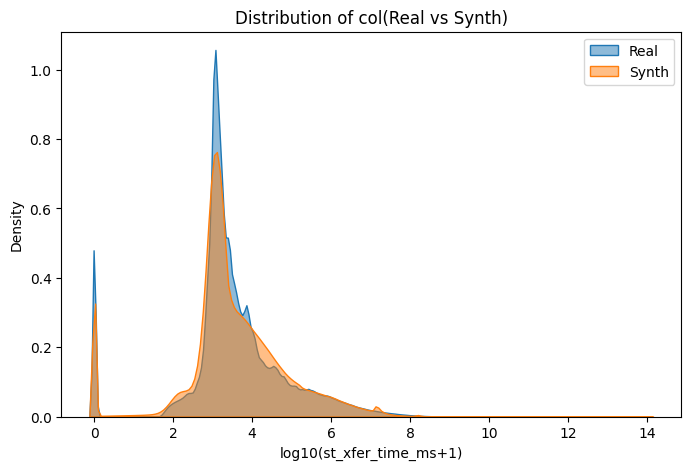

In [6]:
# Plot the distributions
col = "st_xfer_time_ms"
plt.figure(figsize=(8, 5))

real_log = np.log10(real[col].clip(lower=1))
synth_log = np.log10(after[col].clip(lower=1))

sns.kdeplot(real_log, label="Real", fill=True, alpha=0.5)
sns.kdeplot(synth_log, label="Synth", fill=True, alpha=0.5)
plt.title("Distribution of col(Real vs Synth)")
plt.xlabel(f'log10({col}+1)')
plt.ylabel("Density")
plt.legend()
plt.show()


In [8]:
ks_results, wd_results = {}, {}
for col in selected_cols:
    ks = ks_2samp(real[col], synth[col]).statistic
    wd = wasserstein_distance(real[col], synth[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values('KS_stat'))


Distribution similarity (lower is better):
                    KS_stat   Wasserstein
st_failed          0.000142  4.972338e+01
st_expired         0.002648  5.304571e+02
st_canceled        0.010130  9.685890e+02
st_faults          0.025076  5.008462e+00
st_xfer_time_ms    0.038676  1.605341e+06
st_successful      0.059563  1.094230e+04
st_files           0.067801  6.569581e+03
st_files_skipped   0.069250  2.464461e+03
st_dirs            0.069671  3.160707e+02
st_bytes_xfered    0.070460  3.077083e+11
st_skipped_errors  0.499287  1.248507e+00


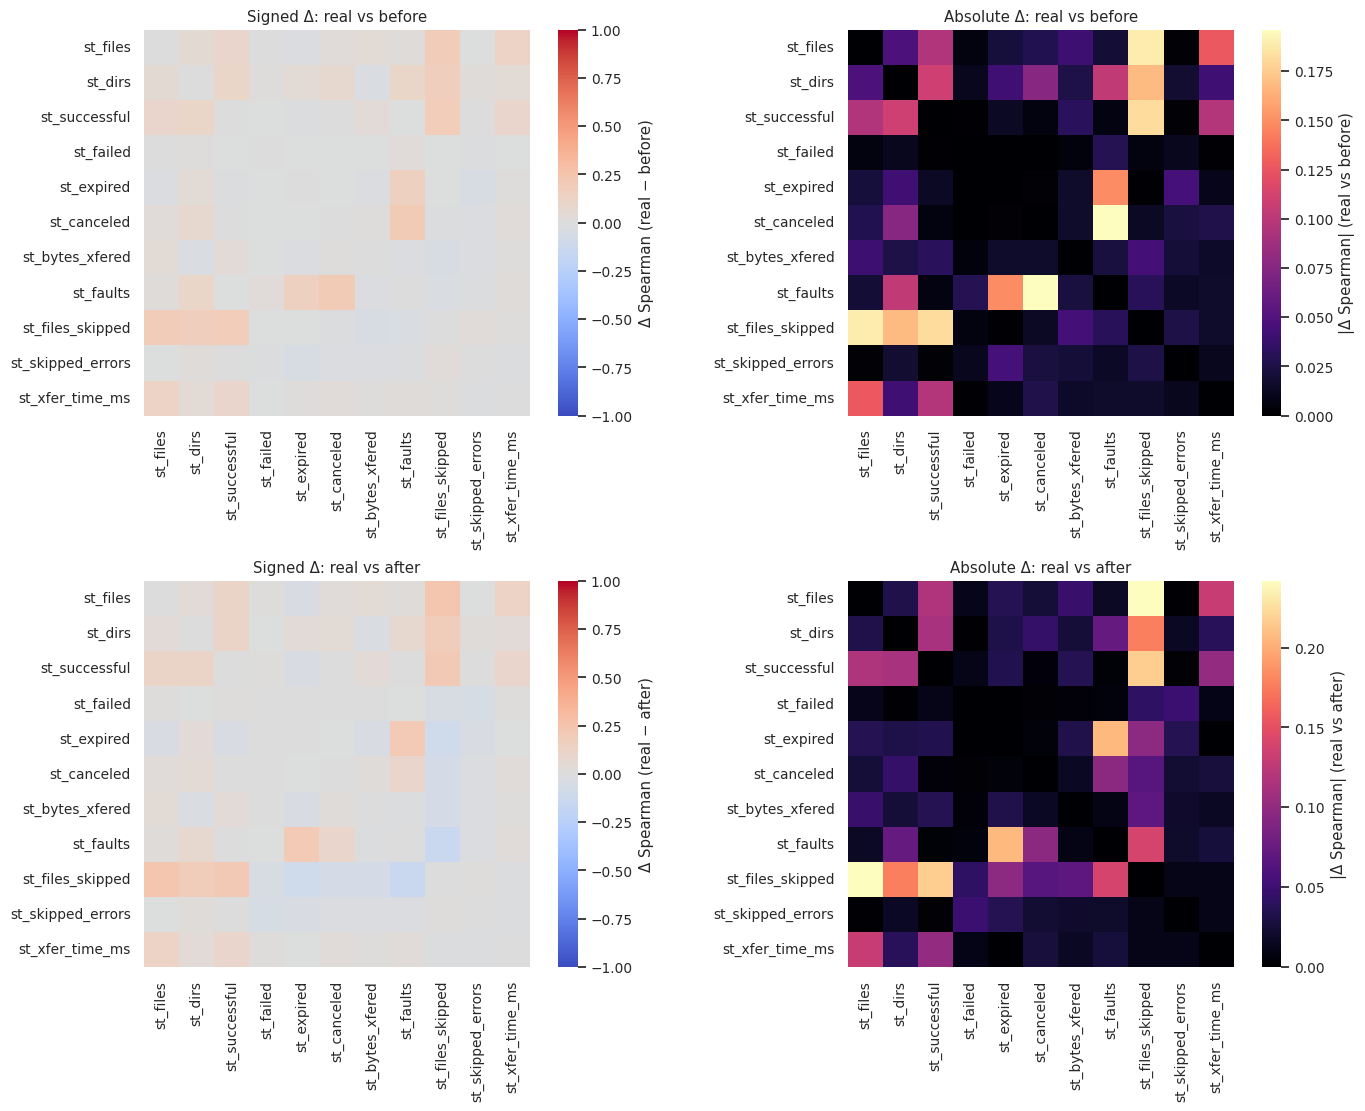

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def corr_diffs(real_df, other_df):
    corr_real = real_df.corr("spearman")
    corr_other = other_df.corr("spearman")
    signed = corr_real - corr_other
    abs_diff = signed.abs()
    return signed, abs_diff

signed_before, abs_before = corr_diffs(real, before)
signed_after,  abs_after  = corr_diffs(real, after)

sns.set_theme(style="white", font="DejaVu Sans", font_scale=0.9)
fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)

heatmap_cfg = dict(square=True)

# real − before (signed)
sns.heatmap(
    signed_before, ax=axes[0, 0],
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    cbar_kws={"label": "Δ Spearman (real − before)"},
    **heatmap_cfg,
)
axes[0, 0].set_title("Signed Δ: real vs before")

# real − before (abs)
sns.heatmap(
    abs_before, ax=axes[0, 1],
    cmap="magma", vmin=0, vmax=abs_before.values.max(),
    cbar_kws={"label": "|Δ Spearman| (real vs before)"},
    **heatmap_cfg,
)
axes[0, 1].set_title("Absolute Δ: real vs before")

# real − after (signed)
sns.heatmap(
    signed_after, ax=axes[1, 0],
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    cbar_kws={"label": "Δ Spearman (real − after)"},
    **heatmap_cfg,
)
axes[1, 0].set_title("Signed Δ: real vs after")

# real − after (abs)
sns.heatmap(
    abs_after, ax=axes[1, 1],
    cmap="magma", vmin=0, vmax=abs_after.values.max(),
    cbar_kws={"label": "|Δ Spearman| (real vs after)"},
    **heatmap_cfg,
)
axes[1, 1].set_title("Absolute Δ: real vs after")

plt.show()


In [11]:
print(np.linalg.norm(signed_before, "fro"))
print(np.linalg.norm(signed_after, "fro"))

0.6962123564521894
0.7860532213019179


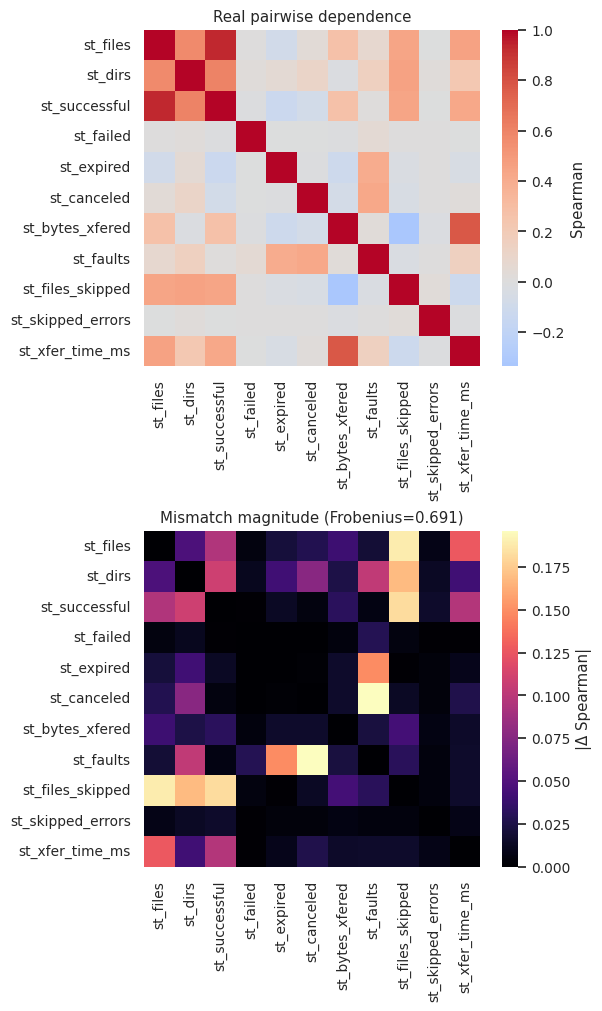

In [8]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# synth = after
def corr_abs_delta(real_df, synth_df):
    signed = real_df.corr("spearman") - synth_df.corr("spearman")
    return signed.abs(), np.linalg.norm(signed, "fro")

abs_delta, fro_norm = corr_abs_delta(real, synth)
sns.set_theme(style="white", font_scale=0.9)
fig, axes = plt.subplots(2, 1, figsize=(6.5, 10), constrained_layout=True)

sns.heatmap(real.corr("spearman"), ax=axes[0], cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Spearman"})
axes[0].set_title("Real pairwise dependence")

sns.heatmap(abs_delta, ax=axes[1], cmap="magma", square=True,
            cbar_kws={"label": "|Δ Spearman|"})
axes[1].set_title(f"Mismatch magnitude (Frobenius={fro_norm:.3f})")

plt.show()

# # Copula-based joint plots for selected pairs
# def to_uniform(df):
#     return df.rank(pct=True)

# u_real, u_synth = to_uniform(real), to_uniform(synth)
# pairs = [("featA", "featB"), ("featC", "featD")]  # pick key pairs

# fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 4*len(pairs)), constrained_layout=True)
# for i, (x, y) in enumerate(pairs):
#     ax = axes[i, 0]
#     sns.kdeplot(data=u_real, x=x, y=y, fill=False, levels=8, color="black", ax=ax, linewidths=1)
#     sns.kdeplot(data=u_synth, x=x, y=y, fill=True, thresh=0.05, cmap="magma", ax=ax, alpha=0.5)
#     ax.set_title(f"Copula density: {x} vs {y} (contours=real, fill=synth)")
#     ax.set_xlim(0,1); ax.set_ylim(0,1)
# plt.show()

